# Some plots for visualisation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

from contextuality import EmpiricalModel, MeasurementScenarioImplementations

## Contextual Fraction vs Signalling Fraction

### Some definitions

MS = Maximally Signalling

CHSH = Clauser-Horne-Shimony-Holt

PR-Box = Popescu-Rohrlich box

In [2]:
chsh = MeasurementScenarioImplementations.chsh()
MS_points = [
    np.array([1, 0, 0, 0,
              1, 0, 0, 0,
              1, 0, 0, 0,
              0, 1, 0, 0]),
    np.array([0, 0, 0, 1,
              0, 0, 0, 1,
              0, 0, 0, 1,
              0, 0, 1, 0]),
    np.array([0, 0, 1, 0,
              0, 0, 1, 0,
              0, 0, 1, 0,
              0, 0, 0, 1]),
    np.array([0, 1, 0, 0,
              0, 1, 0, 0,
              0, 1, 0, 0,
              1, 0, 0, 0])
]

PRBOX = np.array([
    1 / 2, 0, 0, 1 / 2,
    1 / 2, 0, 0, 1 / 2,
    1 / 2, 0, 0, 1 / 2,
    0, 1 / 2, 1 / 2, 0
])

FULLY_MIXED = np.array([
    1 / 4, 1 / 4, 1 / 4, 1 / 4,
    1 / 4, 1 / 4, 1 / 4, 1 / 4,
    1 / 4, 1 / 4, 1 / 4, 1 / 4,
    1 / 4, 1 / 4, 1 / 4, 1 / 4
])

### Computing the quantities

In [3]:
nb_points = 100

x_range = np.linspace(0, 1, nb_points)
y_range = np.linspace(0, 1, nb_points)

y_range_tqdm = tqdm(total=nb_points)
x_range_tqdm = tqdm(total=nb_points)

CFs = np.zeros((nb_points, nb_points))
SFs = np.zeros((nb_points, nb_points))
MIMs = np.zeros((nb_points, nb_points))

for i, y in enumerate(y_range):
    x_range_tqdm.reset()
    y_range_tqdm.update()
    p1 = (1 - y) * MS_points[0] + y * MS_points[1]
    p2 = (1 - y) * MS_points[2] + y * MS_points[3]
    for j, x in enumerate(x_range):
        x_range_tqdm.update()
        p = (1 - x) * p1 + x * p2
        em = EmpiricalModel(chsh, p)
        CFs[j, i] = em.compute_cf()["CF"]
        SFs[j, i] = em.compute_sf()["SF"]

x_range_tqdm.close()
y_range_tqdm.close()

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_157180/2593469283.py:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


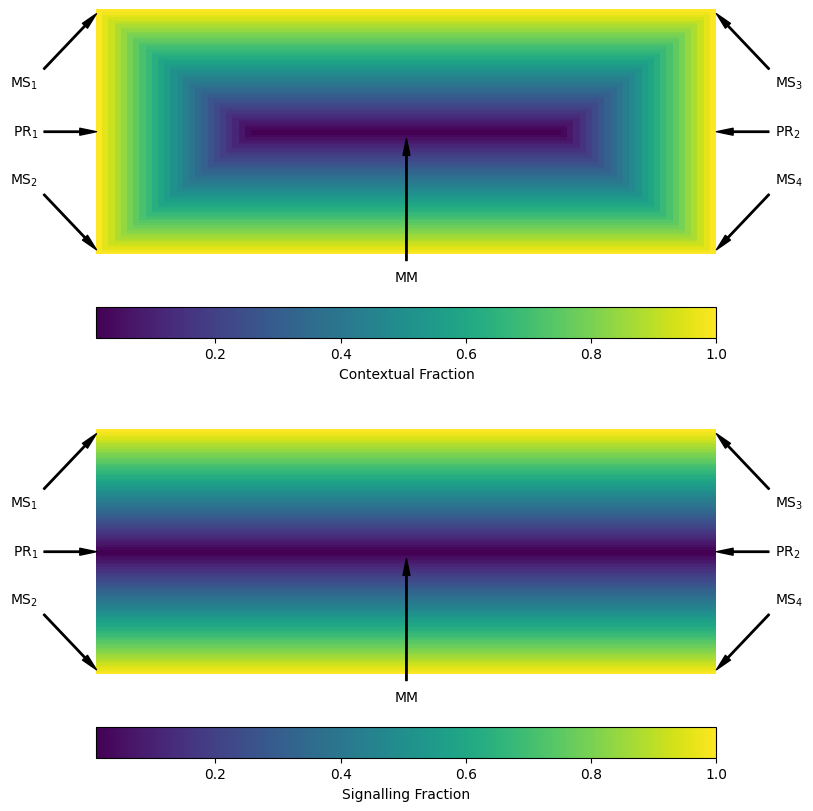

In [15]:
X, Y = np.meshgrid(x_range, y_range)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8,10))

ax1 = axs[0]
ax2 = axs[1]

ax1.set_axis_off()
ax2.set_axis_off()

res = ax1.pcolor(X, Y, CFs.T)
fig.colorbar(res, ax=ax1, label="Contextual Fraction", location="bottom")

annotation_arguments = {'horizontalalignment': 'right',
                        'verticalalignment': 'center',
                        'arrowprops':{'facecolor':'black', 'width': 1, 'headwidth': 5, 'shrink': 0.05}}
ax1.annotate(r"$\text{MS}_1$", xy=(0, 1), xytext=(-0.1, 0.7), **annotation_arguments)
ax1.annotate(r"$\text{PR}_1$", xy=(0, 0.5), xytext=(-0.1, 0.5), **annotation_arguments)
ax1.annotate(r"$\text{MS}_2$", xy=(0, 0), xytext=(-0.1, 0.3), **annotation_arguments)

annotation_arguments['horizontalalignment'] = 'left'

ax1.annotate(r"$\text{MS}_3$", xy=(1, 1), xytext=(1.1, 0.7), **annotation_arguments)
ax1.annotate(r"$\text{PR}_2$", xy=(1, 0.5), xytext=(1.1, 0.5), **annotation_arguments)
ax1.annotate(r"$\text{MS}_4$", xy=(1, 0), xytext=(1.1, 0.3), **annotation_arguments)

annotation_arguments['horizontalalignment'] = 'center'

ax1.annotate(r"MM", xy=(0.5, 0.5), xytext=(0.5, -0.1), **annotation_arguments)

res = ax2.pcolor(X, Y, SFs.T)
fig.colorbar(res, ax=ax2, label="Signalling Fraction", location="bottom")

annotation_arguments = {'horizontalalignment': 'right',
                        'verticalalignment': 'center',
                        'arrowprops':{'facecolor':'black', 'width': 1, 'headwidth': 5, 'shrink': 0.05}}
ax2.annotate(r"$\text{MS}_1$", xy=(0, 1), xytext=(-0.1, 0.7), **annotation_arguments)
ax2.annotate(r"$\text{PR}_1$", xy=(0, 0.5), xytext=(-0.1, 0.5), **annotation_arguments)
ax2.annotate(r"$\text{MS}_2$", xy=(0, 0), xytext=(-0.1, 0.3), **annotation_arguments)

annotation_arguments['horizontalalignment'] = 'left'

ax2.annotate(r"$\text{MS}_3$", xy=(1, 1), xytext=(1.1, 0.7), **annotation_arguments)
ax2.annotate(r"$\text{PR}_2$", xy=(1, 0.5), xytext=(1.1, 0.5), **annotation_arguments)
ax2.annotate(r"$\text{MS}_4$", xy=(1, 0), xytext=(1.1, 0.3), **annotation_arguments)

annotation_arguments['horizontalalignment'] = 'center'

ax2.annotate(r"MM", xy=(0.5, 0.5), xytext=(0.5, -0.1), **annotation_arguments)

fig.show()